# ⚡ PVPC España — Análisis Exploratorio de Datos

**Objetivo:** Explorar el comportamiento del Precio Voluntario para el Pequeño Consumidor (PVPC) en la Península, detectar patrones horarios y semanales, y encontrar anomalías de precio.

**Fuente:** API ESIOS — Red Eléctrica de España  
**Zona:** Península (geo_id: 8741)  
**Frecuencia:** Horaria  
**Unidad:** €/MWh

## 0. Importaciones y configuración

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Añadir src al path para poder importar nuestros módulos
sys.path.append(str(Path.cwd().parent / "src"))
from data.process_data import (
    load_raw_json,
    filter_by_geo,
    clean_data,
    compute_descriptive_stats,
    compute_hourly_profile,
    compute_daily_profile,
    detect_outliers_iqr,
    DATA_RAW_DIR,
)

# --- Estilo global de gráficos ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 4),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 1. Carga y limpieza de datos

In [2]:
# Carga el JSON más reciente disponible en data/raw/
raw_files = sorted(DATA_RAW_DIR.glob("pvpc_*.json"))
latest_file = raw_files[-1]
print(f"Archivo cargado: {latest_file.name}")

# Pipeline de limpieza
df_raw       = load_raw_json(latest_file)
df_peninsula = filter_by_geo(df_raw)
df           = clean_data(df_peninsula)

print(f"\nPeriodo: {df.index.min()} → {df.index.max()}")
print(f"Registros: {len(df)} horas")
df.head()

2026-03-01 15:50:03 [INFO] Cargando archivo: pvpc_2025-08-01_2026-02-28.json
2026-03-01 15:50:03 [INFO] DataFrame cargado: 25440 filas × 6 columnas
2026-03-01 15:50:03 [INFO] Zonas disponibles: ['Baleares', 'Ceuta', 'Melilla', 'Canarias', 'Península']
2026-03-01 15:50:03 [INFO] Zona seleccionada: Península → 5088 registros
2026-03-01 15:50:03 [INFO] Duplicados: ninguno ✓
2026-03-01 15:50:03 [INFO] Valores nulos: ninguno ✓
2026-03-01 15:50:03 [INFO] Continuidad temporal: serie completa sin huecos ✓
2026-03-01 15:50:03 [INFO] DataFrame limpio: 5088 registros desde 2025-08-01 00:00:00+00:00 hasta 2026-02-28 23:00:00+00:00


Archivo cargado: pvpc_2025-08-01_2026-02-28.json

Periodo: 2025-08-01 00:00:00+00:00 → 2026-02-28 23:00:00+00:00
Registros: 5088 horas


,geo_name,precio_eur_mwh
datetime_utc,,
2025-08-01 00:00:00+00:00,Península,124.43
2025-08-01 01:00:00+00:00,Península,112.27
2025-08-01 02:00:00+00:00,Península,103.58
2025-08-01 03:00:00+00:00,Península,113.33
2025-08-01 04:00:00+00:00,Península,124.54


## 2. Estadísticas descriptivas

In [3]:
stats = compute_descriptive_stats(df)

print("ESTADÍSTICAS DEL PRECIO (€/MWh)")
print("-" * 35)
print(f"  Media:             {stats['mean']:.2f} €/MWh")
print(f"  Mediana:           {stats['mediana']:.2f} €/MWh")
print(f"  Desv. típica:      {stats['std']:.2f} €/MWh")
print(f"  Mínimo:            {stats['min']:.2f} €/MWh")
print(f"  Máximo:            {stats['max']:.2f} €/MWh")
print(f"  Rango:             {stats['rango']:.2f} €/MWh")
print(f"  Coef. variación:   {stats['coef_var']:.1f}%")
print(f"  Asimetría:         {stats['asimetria']:.2f}")

# Hora más cara y más barata del periodo
hora_max = df['precio_eur_mwh'].idxmax()
hora_min = df['precio_eur_mwh'].idxmin()
print(f"\n  Hora más cara:     {hora_max} → {df.loc[hora_max, 'precio_eur_mwh']:.2f} €/MWh")
print(f"  Hora más barata:   {hora_min} → {df.loc[hora_min, 'precio_eur_mwh']:.2f} €/MWh")

ESTADÍSTICAS DEL PRECIO (€/MWh)
-----------------------------------
  Media:             136.44 €/MWh
  Mediana:           131.80 €/MWh
  Desv. típica:      53.58 €/MWh
  Mínimo:            22.79 €/MWh
  Máximo:            357.53 €/MWh
  Rango:             334.74 €/MWh
  Coef. variación:   39.3%
  Asimetría:         0.73

  Hora más cara:     2026-02-23 19:00:00+00:00 → 357.53 €/MWh
  Hora más barata:   2025-08-16 12:00:00+00:00 → 22.79 €/MWh


## 3. Serie temporal completa

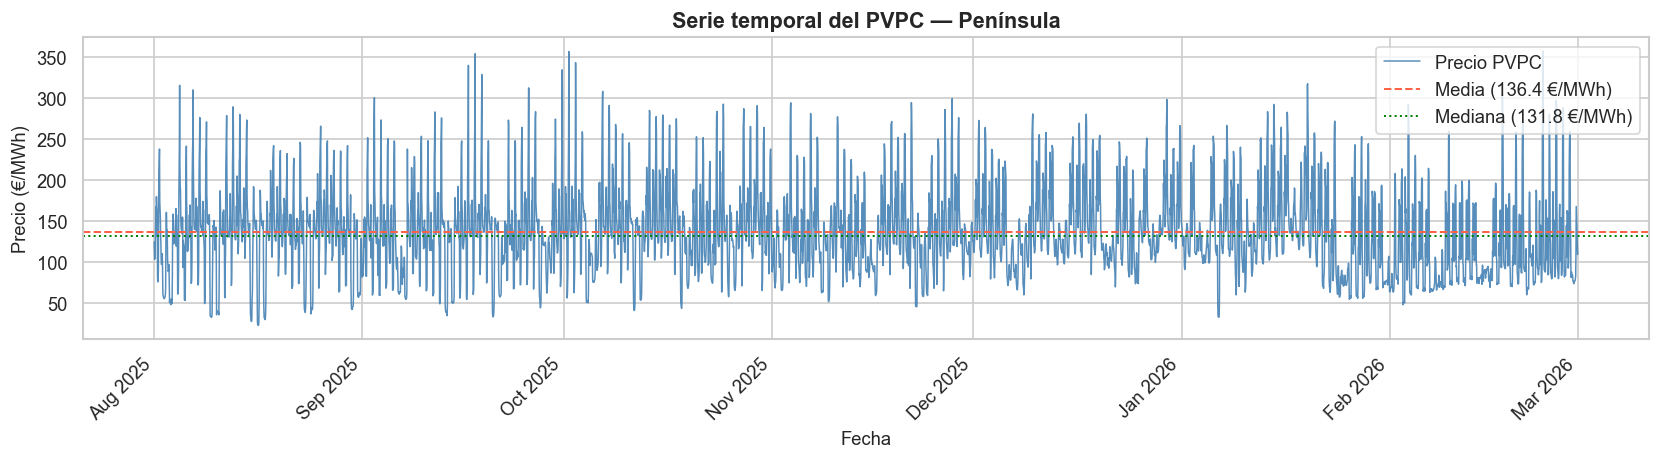

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["precio_eur_mwh"],
        linewidth=0.9, color="steelblue", alpha=0.9, label="Precio PVPC")

# Líneas de referencia: media y mediana
ax.axhline(df["precio_eur_mwh"].mean(),
           color="tomato", linestyle="--", linewidth=1.2, label=f"Media ({df['precio_eur_mwh'].mean():.1f} €/MWh)")
ax.axhline(df["precio_eur_mwh"].median(),
           color="green", linestyle=":", linewidth=1.2, label=f"Mediana ({df['precio_eur_mwh'].median():.1f} €/MWh)")

# Formato del eje X con fechas legibles
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))  # marca lunes (opcional)
plt.xticks(rotation=45, ha="right")

ax.set_title("Serie temporal del PVPC — Península")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (€/MWh)")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("../data/processed/01_serie_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Perfil diario — precio medio por hora

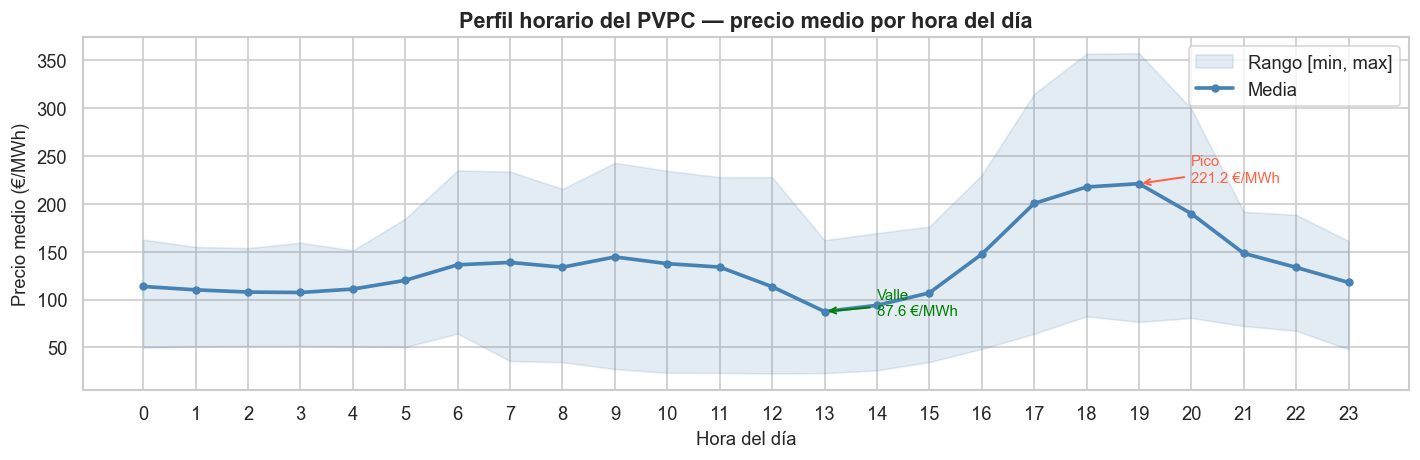

In [5]:
perfil_horario = compute_hourly_profile(df)

fig, ax = plt.subplots(figsize=(12, 4))

# Área de incertidumbre entre mínimo y máximo
ax.fill_between(perfil_horario.index,
                perfil_horario["min"],
                perfil_horario["max"],
                alpha=0.15, color="steelblue", label="Rango [min, max]")

# Línea principal: media
ax.plot(perfil_horario.index, perfil_horario["mean"],
        color="steelblue", linewidth=2.2, marker="o", markersize=4, label="Media")

# Marcar la hora más cara y más barata
hora_cara   = perfil_horario["mean"].idxmax()
hora_barata = perfil_horario["mean"].idxmin()

ax.annotate(f"Pico\n{perfil_horario.loc[hora_cara, 'mean']:.1f} €/MWh",
            xy=(hora_cara, perfil_horario.loc[hora_cara, "mean"]),
            xytext=(hora_cara + 1, perfil_horario.loc[hora_cara, "mean"] + 2),
            fontsize=9, color="tomato",
            arrowprops=dict(arrowstyle="->", color="tomato", lw=1.2))

ax.annotate(f"Valle\n{perfil_horario.loc[hora_barata, 'mean']:.1f} €/MWh",
            xy=(hora_barata, perfil_horario.loc[hora_barata, "mean"]),
            xytext=(hora_barata + 1, perfil_horario.loc[hora_barata, "mean"] - 4),
            fontsize=9, color="green",
            arrowprops=dict(arrowstyle="->", color="green", lw=1.2))

ax.set_title("Perfil horario del PVPC — precio medio por hora del día")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Precio medio (€/MWh)")
ax.set_xticks(range(0, 24))
ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/02_perfil_horario.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Precio medio por día de la semana

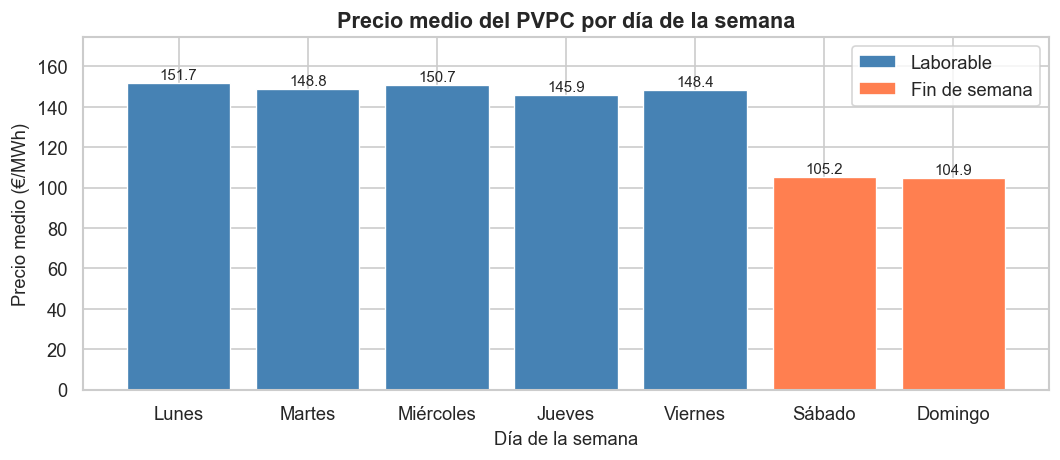

In [6]:
perfil_diario = compute_daily_profile(df)

# Colores distintos para laborables y fin de semana
colores = ["steelblue"] * 5 + ["coral"] * 2

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(perfil_diario.index, perfil_diario.values,
              color=colores, edgecolor="white", linewidth=0.8)

# Etiqueta de valor encima de cada barra
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}",
            ha="center", va="bottom", fontsize=9)

# Leyenda manual para los colores
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor="steelblue", label="Laborable"),
    Patch(facecolor="coral",     label="Fin de semana"),
]
ax.legend(handles=leyenda)

ax.set_title("Precio medio del PVPC por día de la semana")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Precio medio (€/MWh)")
ax.set_ylim(0, perfil_diario.max() * 1.15)

plt.tight_layout()
plt.savefig("../data/processed/03_perfil_semanal.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Heatmap — hora × día de la semana

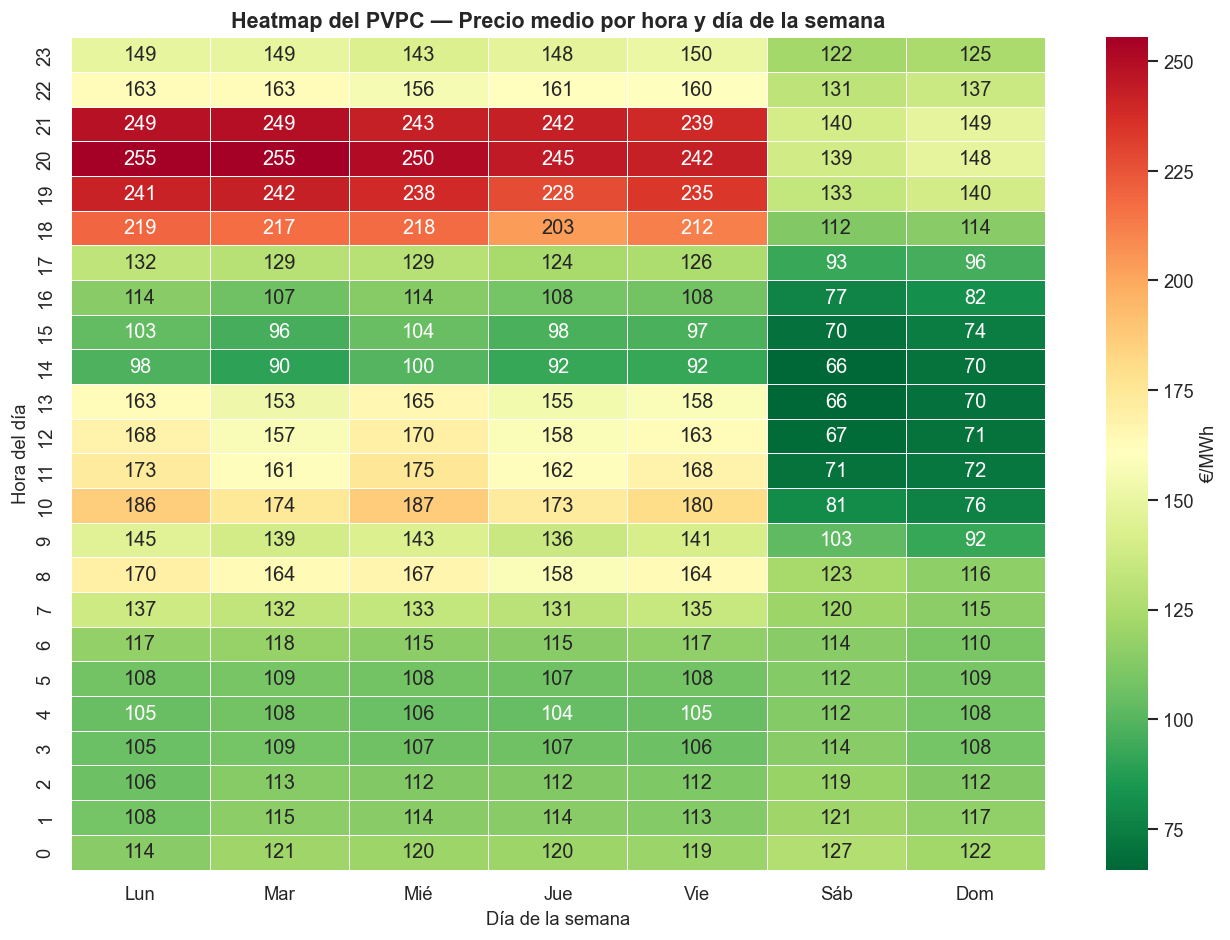

In [7]:
# Construimos una tabla pivote: filas=hora del día, columnas=día semana
df_pivot = df.copy()
df_pivot.index = df_pivot.index.tz_convert("Europe/Madrid")  # ← añadir esta línea
df_pivot["hora"]        = df_pivot.index.hour
df_pivot["dia_semana"]  = df_pivot.index.dayofweek

tabla_pivot = df_pivot.pivot_table(
    values="precio_eur_mwh",
    index="hora",
    columns="dia_semana",
    aggfunc="mean"
).round(1)

# Renombrar columnas con nombres de días
tabla_pivot.columns = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"][:len(tabla_pivot.columns)]

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    tabla_pivot,
    ax=ax,
    cmap="RdYlGn_r",      # rojo=caro, verde=barato
    annot=True,            # muestra el valor en cada celda
    fmt=".0f",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "€/MWh"},
)

ax.set_title("Heatmap del PVPC — Precio medio por hora y día de la semana")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Hora del día")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/04_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Distribución del precio

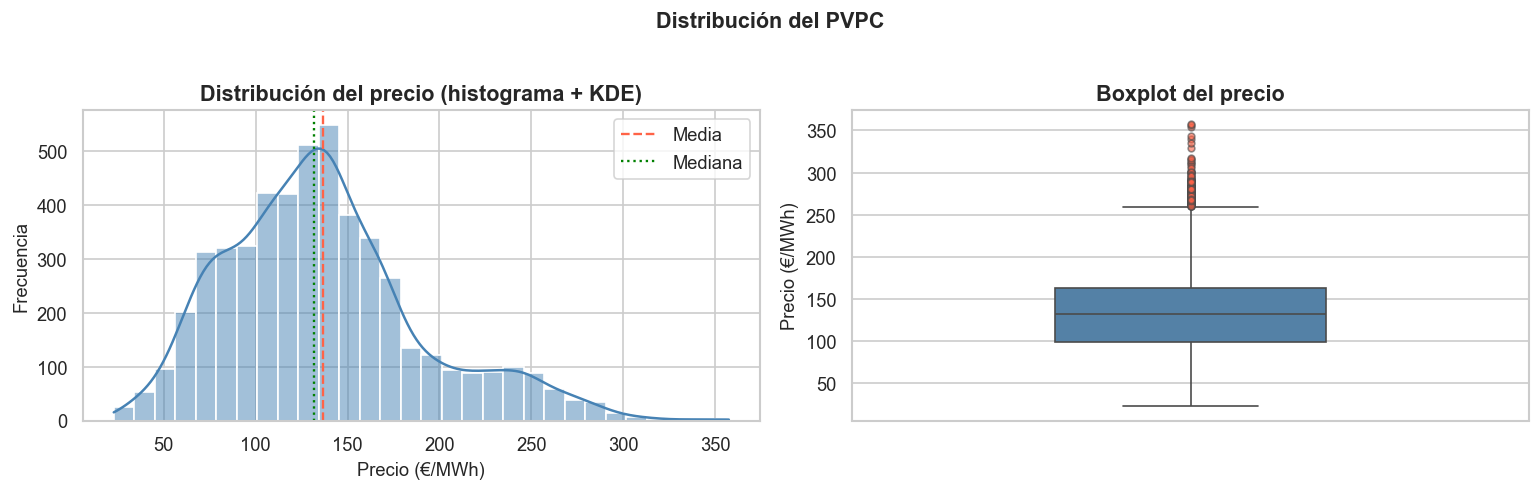

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histograma con curva de densidad ---
sns.histplot(
    df["precio_eur_mwh"],
    ax=axes[0],
    kde=True,              # añade la curva de densidad estimada (KDE)
    bins=30,
    color="steelblue",
    edgecolor="white",
)
axes[0].axvline(df["precio_eur_mwh"].mean(),
                color="tomato", linestyle="--", linewidth=1.4, label="Media")
axes[0].axvline(df["precio_eur_mwh"].median(),
                color="green", linestyle=":", linewidth=1.4, label="Mediana")
axes[0].set_title("Distribución del precio (histograma + KDE)")
axes[0].set_xlabel("Precio (€/MWh)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# --- Boxplot ---
sns.boxplot(
    y=df["precio_eur_mwh"],
    ax=axes[1],
    color="steelblue",
    width=0.4,
    flierprops=dict(marker="o", markerfacecolor="tomato", markersize=4, alpha=0.6),
)
axes[1].set_title("Boxplot del precio")
axes[1].set_ylabel("Precio (€/MWh)")

plt.suptitle("Distribución del PVPC", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/05_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Detección de anomalías (método IQR)

2026-03-01 15:50:05 [INFO] IQR: Q1=99.08, Q3=163.42, IQR=64.34
2026-03-01 15:50:05 [INFO] Límites: [2.56, 259.94] €/MWh
2026-03-01 15:50:05 [INFO] Outliers detectados: 148 (2.9% del total)


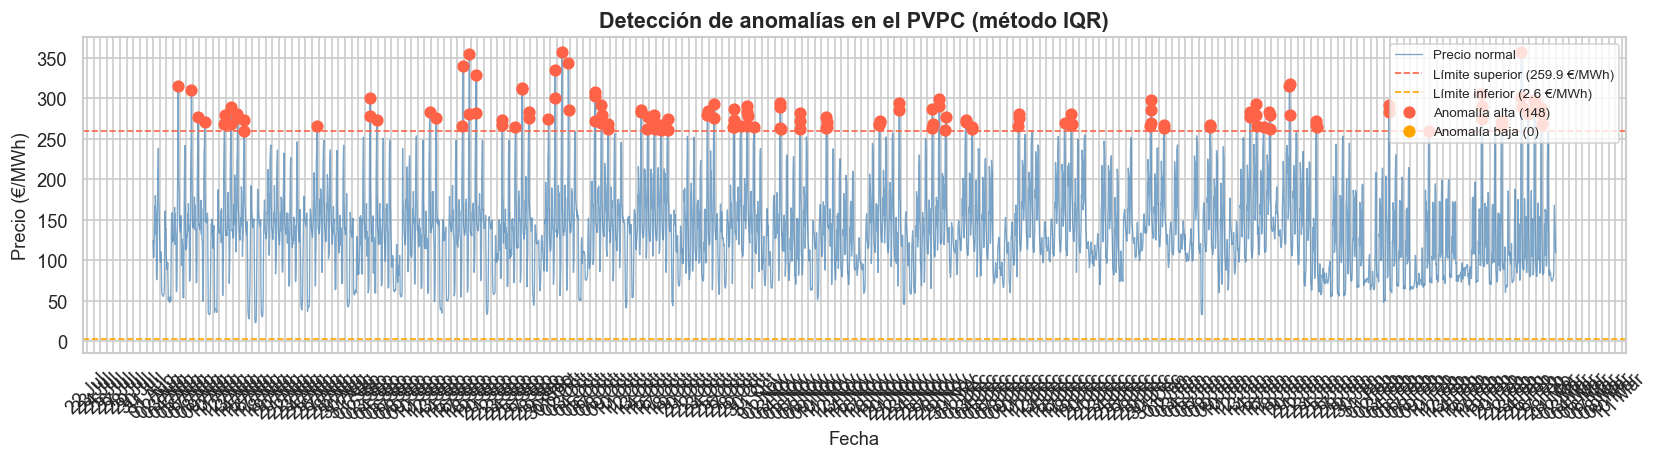


148 anomalías detectadas:
                           precio_eur_mwh  tipo  desviacion_iqr
datetime_utc                                                   
2025-08-04 19:00:00+00:00          315.71  alto            2.86
2025-08-06 19:00:00+00:00          310.16  alto            2.77
2025-08-07 19:00:00+00:00          276.48  alto            2.25
2025-08-08 19:00:00+00:00          271.11  alto            2.16
2025-08-11 18:00:00+00:00          267.76  alto            2.11
2025-08-11 19:00:00+00:00          278.82  alto            2.28
2025-08-12 18:00:00+00:00          289.50  alto            2.45
2025-08-12 19:00:00+00:00          267.90  alto            2.12
2025-08-13 18:00:00+00:00          280.20  alto            2.31
2025-08-13 19:00:00+00:00          275.56  alto            2.23
2025-08-14 18:00:00+00:00          260.10  alto            1.99
2025-08-14 19:00:00+00:00          273.43  alto            2.20
2025-08-25 19:00:00+00:00          265.88  alto            2.08
2025-09-02 18

In [9]:
outliers = detect_outliers_iqr(df, factor=1.5)

q1  = df["precio_eur_mwh"].quantile(0.25)
q3  = df["precio_eur_mwh"].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

fig, ax = plt.subplots(figsize=(14, 4))

# Serie temporal de fondo
ax.plot(df.index, df["precio_eur_mwh"],
        color="steelblue", linewidth=0.8, alpha=0.7, label="Precio normal")

# Franjas de límites
ax.axhline(limite_sup, color="tomato", linestyle="--", linewidth=1, label=f"Límite superior ({limite_sup:.1f} €/MWh)")
ax.axhline(limite_inf, color="orange", linestyle="--", linewidth=1, label=f"Límite inferior ({limite_inf:.1f} €/MWh)")

# Marcar outliers con puntos rojos
if not outliers.empty:
    outliers_altos = outliers[outliers["tipo"] == "alto"]
    outliers_bajos = outliers[outliers["tipo"] == "bajo"]

    ax.scatter(outliers_altos.index, outliers_altos["precio_eur_mwh"],
               color="tomato", s=40, zorder=5, label=f"Anomalía alta ({len(outliers_altos)})")
    ax.scatter(outliers_bajos.index, outliers_bajos["precio_eur_mwh"],
               color="orange", s=40, zorder=5, label=f"Anomalía baja ({len(outliers_bajos)})")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)

ax.set_title("Detección de anomalías en el PVPC (método IQR)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (€/MWh)")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/06_anomalias.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla resumen de outliers
if not outliers.empty:
    print(f"\n{len(outliers)} anomalías detectadas:")
    print(outliers[["precio_eur_mwh", "tipo", "desviacion_iqr"]].to_string())
else:
    print("No se detectaron anomalías en el período analizado.")

## 9. Conclusiones

**Patrón horario:** Se identifican dos picos de precio: uno matutino (7-8h)
coincidiendo con el arranque industrial, y uno vespertino más intenso (19-21h)
con la demanda doméstica. El valle diario ocurre a mediodía (14-16h), 
probablemente influido por la producción solar.

**Patrón semanal:** Los días laborables son ~30% más caros que el fin de semana,
reflejo de la menor demanda industrial en sábado y domingo.

**Distribución:** El precio presenta asimetría positiva (1.42), con una cola
derecha pronunciada. La media (130 €/MWh) supera significativamente a la 
mediana (102 €/MWh), indicando que los picos vespertinos distorsionan el promedio.

**Anomalías:** 14 horas (7.3%) superan el límite IQR superior (257 €/MWh),
concentradas en la franja 19-21h de días laborables, lo que sugiere que son
picos estructurales del mercado más que errores de datos.